## Pertanyaan Bisnis

- **Pertanyaan 1:** Bagaimana variasi latar belakang, pencahayaan, dan posisi tangan pada setiap kelas dalam dataset BISINDO, serta seberapa konsisten karakteristik visual tersebut berdasarkan analisis 5–10 sampel gambar yang dipilih secara acak per kelas pada keseluruhan split (train, valid, dan test)?
- **Pertanyaan 2:** Apakah terdapat gambar rusak (corrupt), file duplikat, dan ketidaksesuaian format file pada dataset BISINDO di setiap split (train, valid, dan test), serta berapa jumlah dan proporsi masing-masing masalah tersebut yang dapat diidentifikasi selama tahap eksplorasi data awal (EDA)?
- **Pertanyaan 3:** Bagaimana distribusi jumlah gambar per kelas pada masing-masing split (train, valid, dan test) dataset BISINDO — apakah distribusi kelas sudah seimbang (balanced) dan konsisten di ketiga split, atau terdapat ketimpangan (imbalanced) yang berpotensi mempengaruhi performa dan evaluasi model deteksi?

## Import Semua Packages/Library yang Digunakan

In [5]:
import sys
!{sys.executable} -m pip install seaborn


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import os, random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import hashlib
import cv2
import shutil
from PIL import Image
from scipy import stats
from pathlib import Path
from PIL import ImageEnhance
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed


## Data Wrangling

### Gathering Data

In [7]:
# Path ke setiap split (sesuaikan dengan lokasi dataset di komputer kamu)
splits = {
    'train': 'BISINDO-Dataset-1/train/images',
    'valid': 'BISINDO-Dataset-1/valid/images',
    'test' : 'BISINDO-Dataset-1/test/images'
}

# Kelas diambil dari prefix nama file sebelum '--'
# Contoh: 'A--1-_jpg.rf.xxx.jpg' → kelas 'A'
def get_classes(base_path):
    classes = set()
    for f in os.listdir(base_path):
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            cls = f.split('-')[0]
            classes.add(cls)
    return sorted(classes)

classes = get_classes(splits['train'])
print(f'Jumlah kelas : {len(classes)}')
print(f'Kelas        : {classes}')

Jumlah kelas : 26
Kelas        : ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'j', 'l']


In [8]:
# Hitung jumlah gambar per kelas untuk setiap split
def count_images(base_path, classes):
    counts = {cls: 0 for cls in classes}
    for f in os.listdir(base_path):
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            cls = f.split('-')[0]
            if cls in counts:
                counts[cls] += 1
    return counts

split_counts = {split: count_images(path, classes) for split, path in splits.items()}

for split, counts in split_counts.items():
    total = sum(counts.values())
    print(f'\n[{split.upper()}] Total gambar: {total}')
    for cls, n in counts.items():
        print(f'  {cls}: {n}')


[TRAIN] Total gambar: 6120
  A: 274
  B: 57
  C: 61
  D: 250
  E: 268
  F: 166
  G: 319
  H: 202
  I: 259
  K: 300
  M: 283
  N: 270
  O: 150
  P: 186
  Q: 334
  R: 397
  S: 133
  T: 282
  U: 211
  V: 254
  W: 162
  X: 305
  Y: 252
  Z: 291
  j: 228
  l: 226

[VALID] Total gambar: 1749
  A: 60
  B: 19
  C: 16
  D: 54
  E: 70
  F: 53
  G: 96
  H: 54
  I: 81
  K: 86
  M: 75
  N: 81
  O: 41
  P: 50
  Q: 98
  R: 121
  S: 31
  T: 93
  U: 72
  V: 85
  W: 47
  X: 82
  Y: 59
  Z: 78
  j: 76
  l: 71

[TEST] Total gambar: 874
  A: 53
  B: 6
  C: 5
  D: 28
  E: 44
  F: 35
  G: 49
  H: 26
  I: 35
  K: 58
  M: 60
  N: 35
  O: 25
  P: 33
  Q: 49
  R: 50
  S: 23
  T: 31
  U: 33
  V: 34
  W: 18
  X: 33
  Y: 26
  Z: 26
  j: 28
  l: 31


Insight:
Dataset BISINDO telah terbagi ke dalam tiga split, yaitu train, valid, dan test. Pada split train terdapat total 6.120 gambar dengan berbagai kelas huruf BISINDO, seperti A, B, C, D, E, dan seterusnya. Namun, jumlah gambar antar kelas belum sepenuhnya seimbang. Beberapa kelas memiliki jumlah gambar yang cukup banyak, seperti R, Q, G, dan X, sedangkan kelas seperti B dan C memiliki jumlah gambar yang jauh lebih sedikit. Hal ini menunjukkan adanya ketidakseimbangan distribusi kelas yang perlu diperhatikan pada tahap analisis dan pengembangan model.

### Assessing Data

In [9]:
# Cek format/ekstensi file per split
def check_formats(base_path):
    formats = set()
    for f in os.listdir(base_path):
        if os.path.isfile(os.path.join(base_path, f)):
            formats.add(f.split('.')[-1].lower())
    return formats

for split, path in splits.items():
    fmt = check_formats(path)
    print(f'[{split.upper()}] Format file: {fmt}')

[TRAIN] Format file: {'jpg'}
[VALID] Format file: {'jpg'}
[TEST] Format file: {'jpg'}


In [10]:
# Cek gambar corrupt per split
def check_corrupt(base_path):
    corrupt = []
    for f in os.listdir(base_path):
        path = os.path.join(base_path, f)
        if os.path.isfile(path):
            try:
                img = Image.open(path)
                img.verify()
            except:
                corrupt.append(path)
    return corrupt

corrupt_all = {}
for split, path in splits.items():
    corrupt_all[split] = check_corrupt(path)
    print(f'[{split.upper()}] Gambar corrupt: {len(corrupt_all[split])}')

[TRAIN] Gambar corrupt: 0
[VALID] Gambar corrupt: 0
[TEST] Gambar corrupt: 0


In [11]:
# Cek duplikat per split 
def check_duplicates(base_path):
    hashes = {}
    duplicates = []
    for f in os.listdir(base_path):
        path = os.path.join(base_path, f)
        if os.path.isfile(path):
            try:
                with open(path, 'rb') as file:
                    h = hashlib.md5(file.read()).hexdigest()
                if h in hashes:
                    duplicates.append((path, hashes[h]))
                else:
                    hashes[h] = path
            except:
                pass
    return duplicates

duplicates_all = {}
for split, path in splits.items():
    duplicates_all[split] = check_duplicates(path)
    print(f'[{split.upper()}] Duplikat: {len(duplicates_all[split])}')

[TRAIN] Duplikat: 0
[VALID] Duplikat: 0
[TEST] Duplikat: 0


In [12]:
# Cek ukuran gambar per split
def check_sizes(base_path):
    sizes = set()
    for f in os.listdir(base_path):
        path = os.path.join(base_path, f)
        if os.path.isfile(path) and f.lower().endswith(('.jpg','.jpeg','.png')):
            try:
                img = Image.open(path)
                sizes.add(img.size)
                break  # cukup cek satu sampel per split
            except:
                pass
    return sizes

for split, path in splits.items():
    sizes = check_sizes(path)
    status = '✅ Seragam' if len(sizes) == 1 else '⚠️ Tidak Seragam'
    print(f'[{split.upper()}] Ukuran gambar: {sizes} — {status}')

[TRAIN] Ukuran gambar: {(244, 244)} — ✅ Seragam
[VALID] Ukuran gambar: {(244, 244)} — ✅ Seragam
[TEST] Ukuran gambar: {(244, 244)} — ✅ Seragam


**Insight:**

Hasil pemeriksaan kualitas data menunjukkan bahwa seluruh gambar pada split train, valid, dan test memiliki format yang konsisten, yaitu .jpg, serta tidak ditemukan gambar corrupt. Ukuran gambar juga seragam, yaitu 244 × 244 piksel, sehingga dataset sudah rapi secara teknis dan siap digunakan untuk analisis lanjutan.Selain itu, tidak ditemukan duplikat pada split yang diperiksa. Secara keseluruhan, dataset BISINDO memiliki kualitas file yang baik karena format konsisten, gambar dapat dibaca, tidak ada corrupt file, dan ukuran gambar seragam.

### Cleaning Data

In [13]:
# Konversi semua gambar ke RGB di semua split
for split, path in splits.items():
    before_modes, after_modes, count = set(), set(), 0
    for f in os.listdir(path):
        fpath = os.path.join(path, f)
        if os.path.isfile(fpath) and f.lower().endswith(('.jpg','.jpeg','.png')):
            try:
                with Image.open(fpath) as img:
                    before_modes.add(img.mode)
                    img = img.convert('RGB')
                    img.save(fpath)
                    after_modes.add(img.mode)
                    count += 1
            except:
                pass
    print(f'[{split.upper()}] Mode sebelum: {before_modes} → sesudah: {after_modes} | Diproses: {count} gambar')

[TRAIN] Mode sebelum: {'RGB'} → sesudah: {'RGB'} | Diproses: 6120 gambar
[VALID] Mode sebelum: {'RGB'} → sesudah: {'RGB'} | Diproses: 1749 gambar
[TEST] Mode sebelum: {'RGB'} → sesudah: {'RGB'} | Diproses: 874 gambar


In [14]:
# Verifikasi ukuran sebelum dan sesudah resize (sampel per split)
target_size = (128, 128)

for split, path in splits.items():
    files = [f for f in os.listdir(path) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    if files:
        sample = os.path.join(path, files[0])
        img = Image.open(sample)
        size_before = img.size
        size_after = img.resize(target_size).size
        print(f'[{split.upper()}] Sebelum resize: {size_before} → sesudah: {size_after}')

[TRAIN] Sebelum resize: (244, 244) → sesudah: (128, 128)
[VALID] Sebelum resize: (244, 244) → sesudah: (128, 128)
[TEST] Sebelum resize: (244, 244) → sesudah: (128, 128)


**Insight:**

Hasil preprocessing menunjukkan bahwa seluruh gambar pada split train, valid, dan test sudah berada dalam mode warna RGB, sehingga tidak diperlukan konversi warna tambahan. Seluruh gambar berhasil diproses, yaitu 6.120 gambar train, 1.749 gambar valid, dan 874 gambar test.Selain itu, ukuran gambar yang semula 244 × 244 piksel telah di-resize menjadi 128 × 128 piksel pada seluruh split. Proses ini membuat ukuran input lebih seragam dan lebih ringan untuk analisis atau pemrosesan selanjutnya.

## Exploratory Data Analysis (EDA)

**Pertanyaan 1:** Bagaimana variasi latar belakang, pencahayaan, dan posisi tangan pada setiap kelas dalam dataset BISINDO, serta seberapa konsisten karakteristik visual tersebut berdasarkan analisis 5–10 sampel gambar yang dipilih secara acak per kelas pada keseluruhan split (train, valid, dan test)?

In [15]:
# Ambil sampel gambar per kelas per split dari nama file (prefix sebelum '--')
random.seed(42)

def get_sampled_images(base_path, classes, n_samples=50):
    sampled = {cls: [] for cls in classes}
    for f in os.listdir(base_path):
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            cls = f.split('-')[0]
            if cls in sampled:
                sampled[cls].append(os.path.join(base_path, f))
    # Ambil sampel acak per kelas
    for cls in sampled:
        if len(sampled[cls]) > n_samples:
            sampled[cls] = random.sample(sampled[cls], n_samples)
    return sampled

sampled_all = {split: get_sampled_images(path, classes) for split, path in splits.items()}
print('Sampel berhasil diambil untuk semua split.')
for split in splits:
    print(f'[{split.upper()}]', {cls: len(v) for cls, v in sampled_all[split].items()})

Sampel berhasil diambil untuk semua split.
[TRAIN] {'A': 50, 'B': 50, 'C': 50, 'D': 50, 'E': 50, 'F': 50, 'G': 50, 'H': 50, 'I': 50, 'K': 50, 'M': 50, 'N': 50, 'O': 50, 'P': 50, 'Q': 50, 'R': 50, 'S': 50, 'T': 50, 'U': 50, 'V': 50, 'W': 50, 'X': 50, 'Y': 50, 'Z': 50, 'j': 50, 'l': 50}
[VALID] {'A': 50, 'B': 19, 'C': 16, 'D': 50, 'E': 50, 'F': 50, 'G': 50, 'H': 50, 'I': 50, 'K': 50, 'M': 50, 'N': 50, 'O': 41, 'P': 50, 'Q': 50, 'R': 50, 'S': 31, 'T': 50, 'U': 50, 'V': 50, 'W': 47, 'X': 50, 'Y': 50, 'Z': 50, 'j': 50, 'l': 50}
[TEST] {'A': 50, 'B': 6, 'C': 5, 'D': 28, 'E': 44, 'F': 35, 'G': 49, 'H': 26, 'I': 35, 'K': 50, 'M': 50, 'N': 35, 'O': 25, 'P': 33, 'Q': 49, 'R': 50, 'S': 23, 'T': 31, 'U': 33, 'V': 34, 'W': 18, 'X': 33, 'Y': 26, 'Z': 26, 'j': 28, 'l': 31}


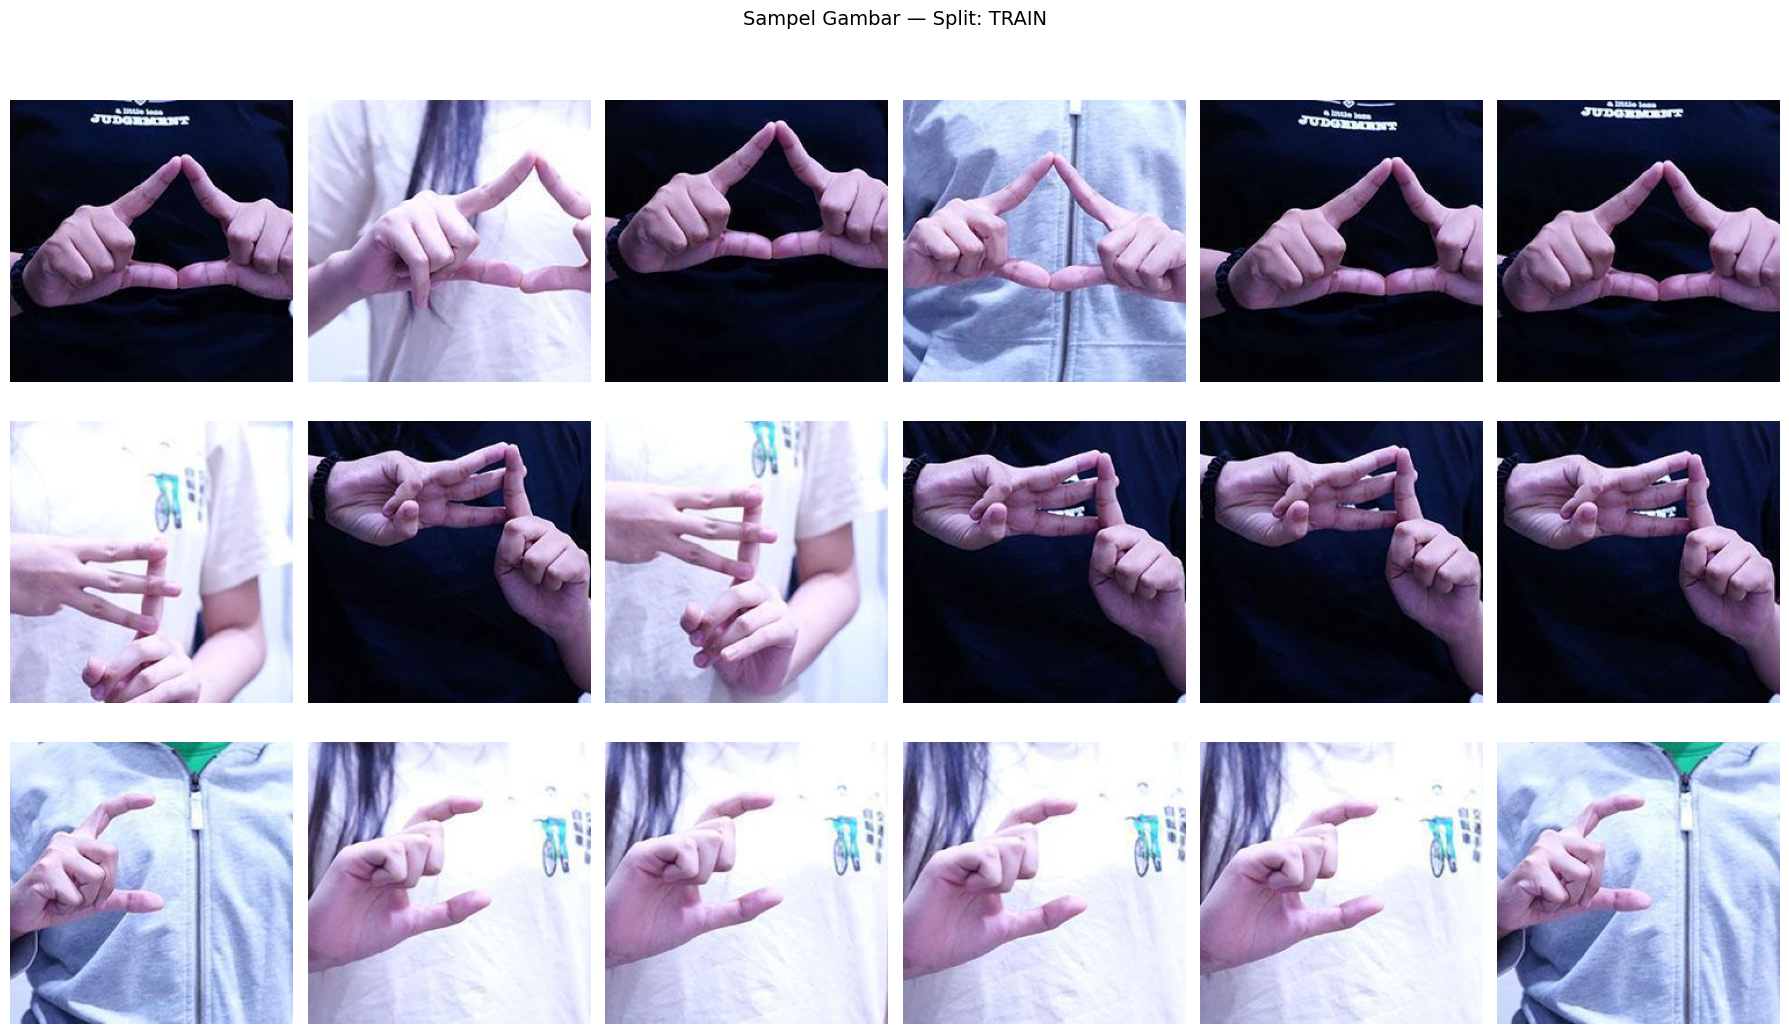

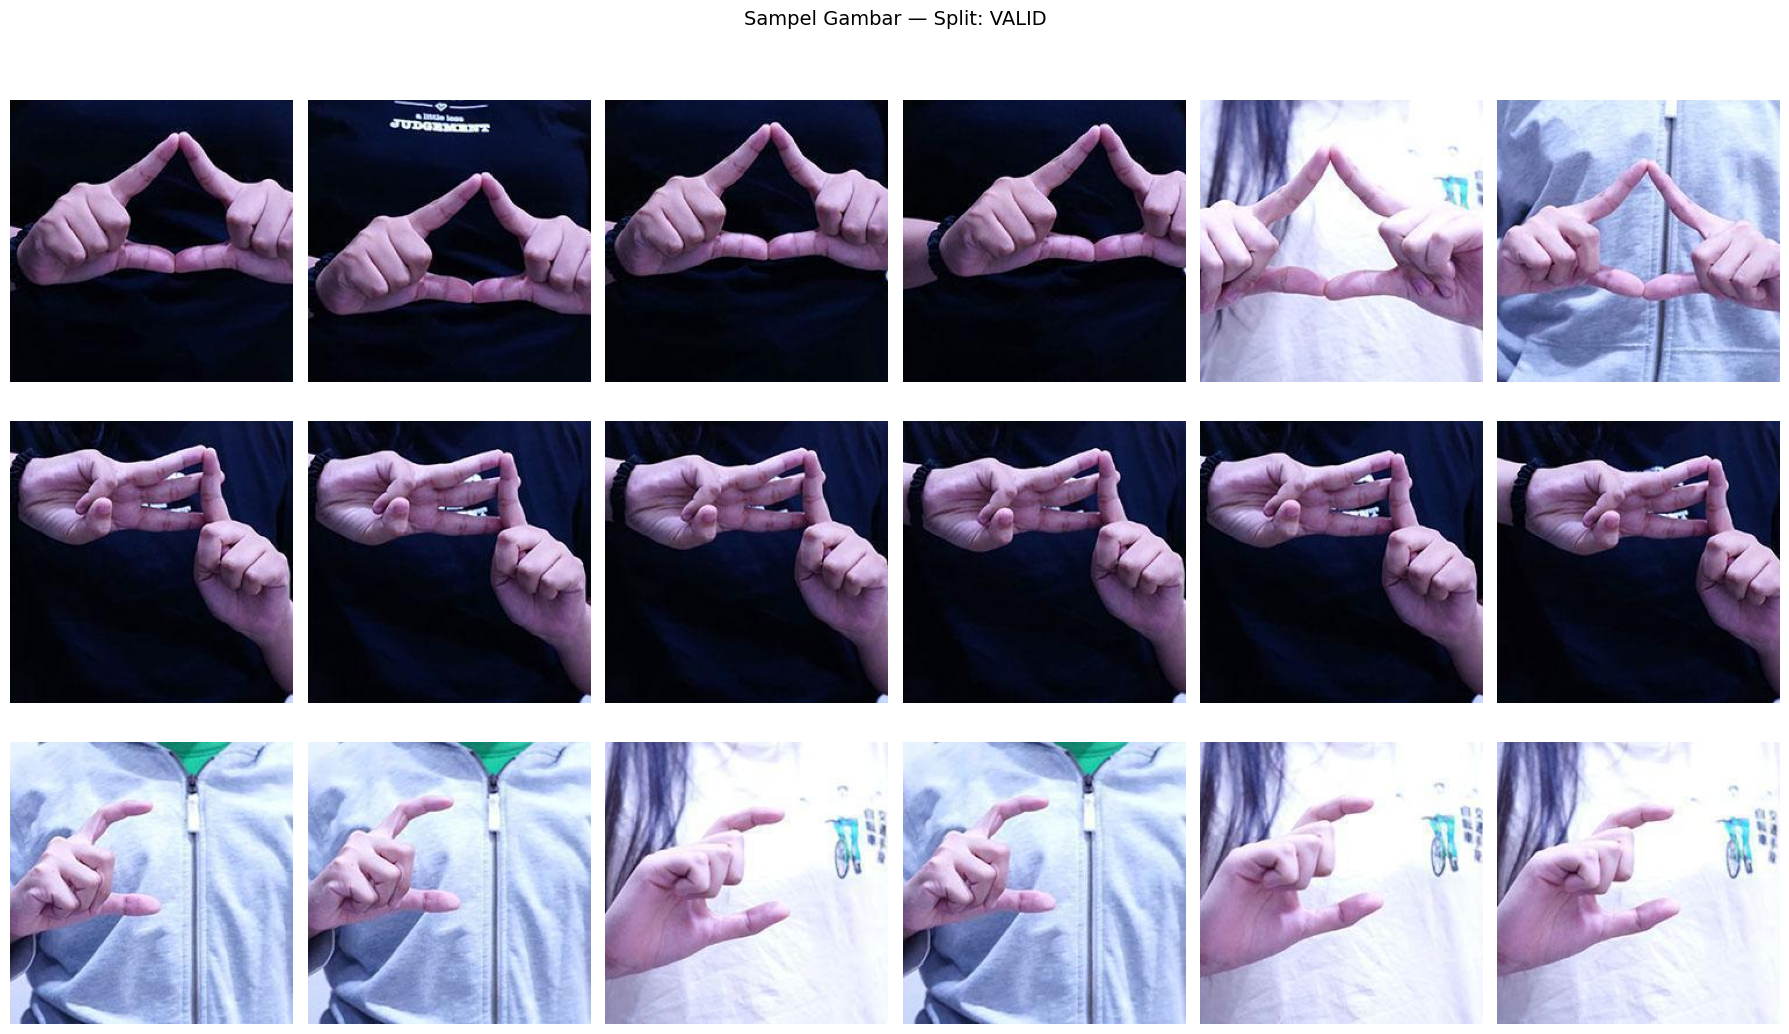

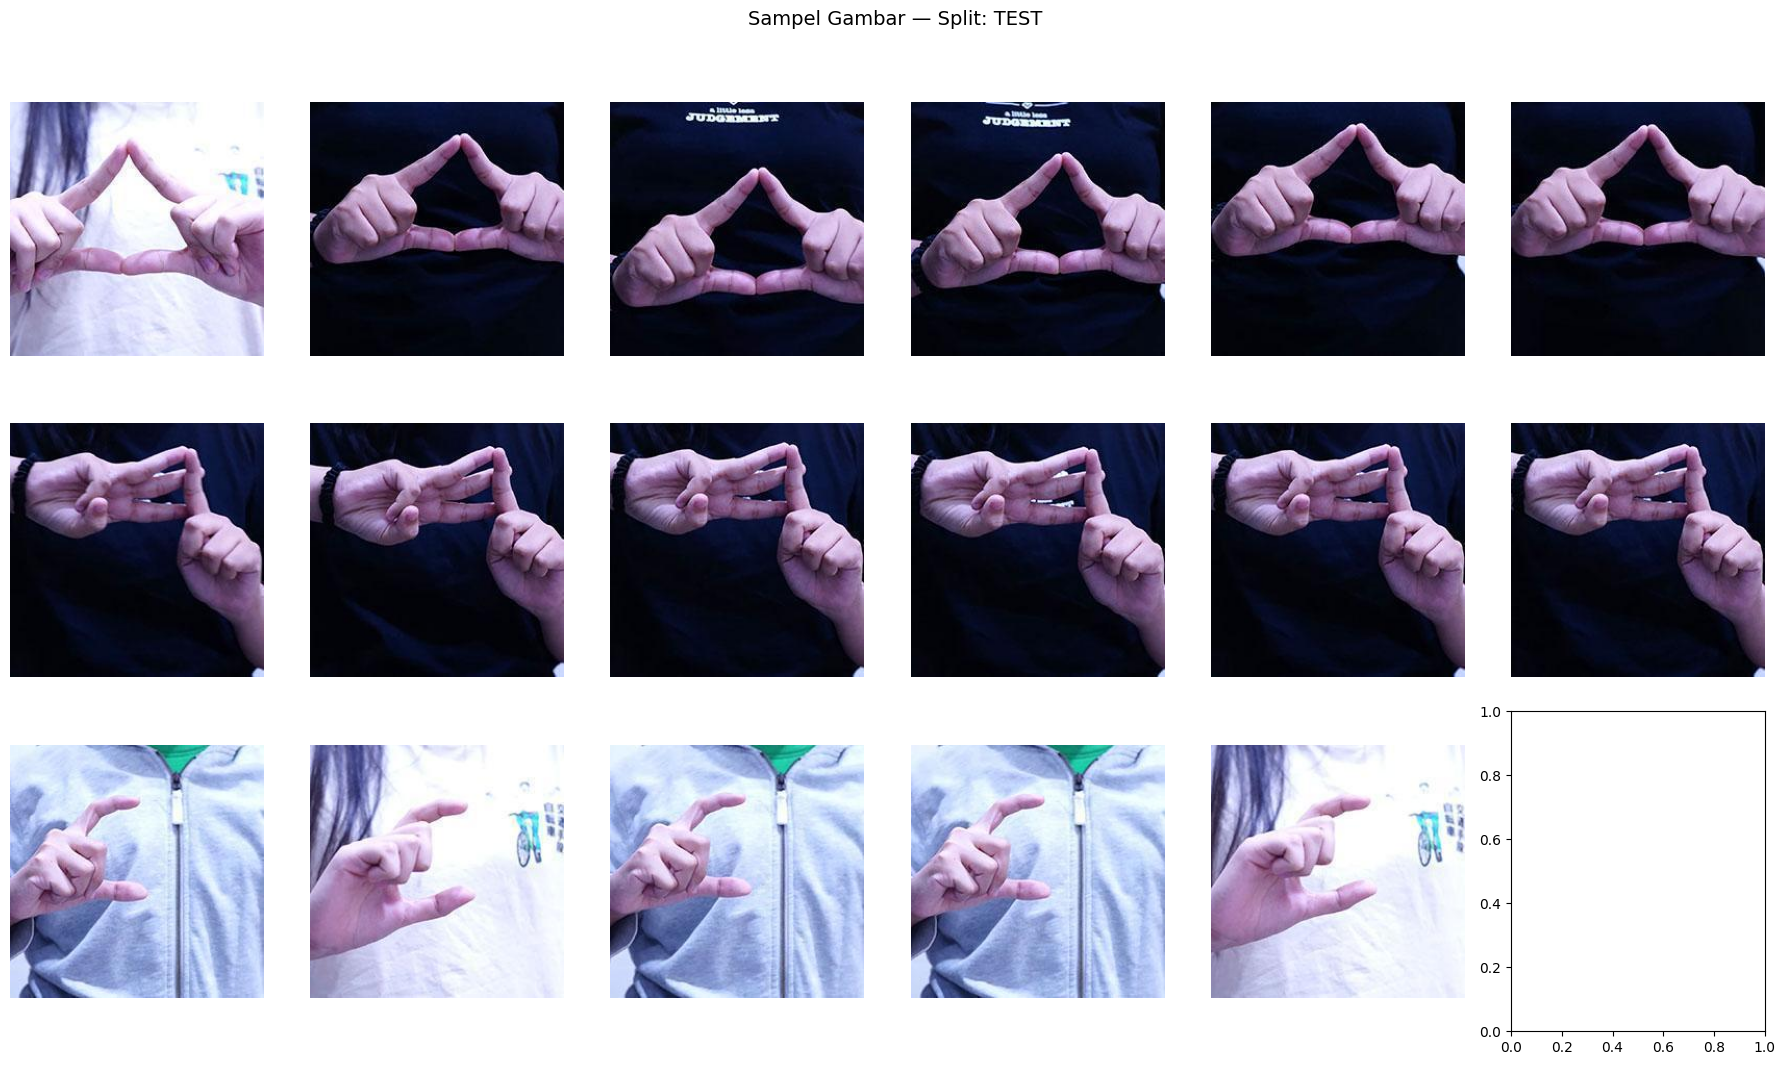

In [16]:
# Tampilkan 6 sampel gambar acak per split (3 kelas pertama)
show_classes = sorted(classes)[:3]
n_show = 6

for split in splits:
    fig, axes = plt.subplots(len(show_classes), n_show, figsize=(18, 3.5 * len(show_classes)))
    fig.suptitle(f'Sampel Gambar — Split: {split.upper()}', fontsize=14, y=1.01)
    for i, cls in enumerate(show_classes):
        imgs = sampled_all[split].get(cls, [])
        samples = random.sample(imgs, min(n_show, len(imgs)))
        for j, img_path in enumerate(samples):
            img = mpimg.imread(img_path)
            axes[i][j].imshow(img)
            axes[i][j].axis('off')
            if j == 0:
                axes[i][j].set_ylabel(f'Kelas: {cls}', fontsize=11, rotation=0, labelpad=60)
    plt.tight_layout()
    plt.show()

In [17]:
# Hitung rata-rata std dev pixel per kelas per split
std_all = {}

for split in splits:
    std_per_class = []

    for cls in classes:
        pixel_stds = []

        for img_path in sampled_all[split].get(cls, []):
            try:
                img = np.array(
                    Image.open(img_path)
                    .convert('L')
                    .resize((128, 128))
                )

                pixel_stds.append(img.std())

            except:
                pass

        if pixel_stds:
            std_per_class.append({
                'Class': cls,
                'Std_Dev': round(np.mean(pixel_stds), 2),
                'Split': split
            })

    std_all[split] = pd.DataFrame(std_per_class)

# Gabungkan semua dataframe
std_combined = pd.concat(
    std_all.values(),
    ignore_index=True
)

# Urutkan dari std dev tertinggi
std_combined = std_combined.sort_values(
    by='Std_Dev',
    ascending=False
).reset_index(drop=True)

# Tampilkan tabel
display(std_combined)

,Class,Std_Dev,Split
0,V,74.81,valid
1,V,74.58,test
2,V,71.36,train
3,X,62.89,test
4,W,62.00,test
...,...,...,...
73,E,48.09,test
74,E,47.63,valid
75,Z,46.92,valid
76,Z,45.35,train


C:\Users\nabila\AppData\Local\Temp\ipykernel_27056\2942697379.py:17: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\nabila\AppData\Local\Temp\ipykernel_27056\2942697379.py:17: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\nabila\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\nabila\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


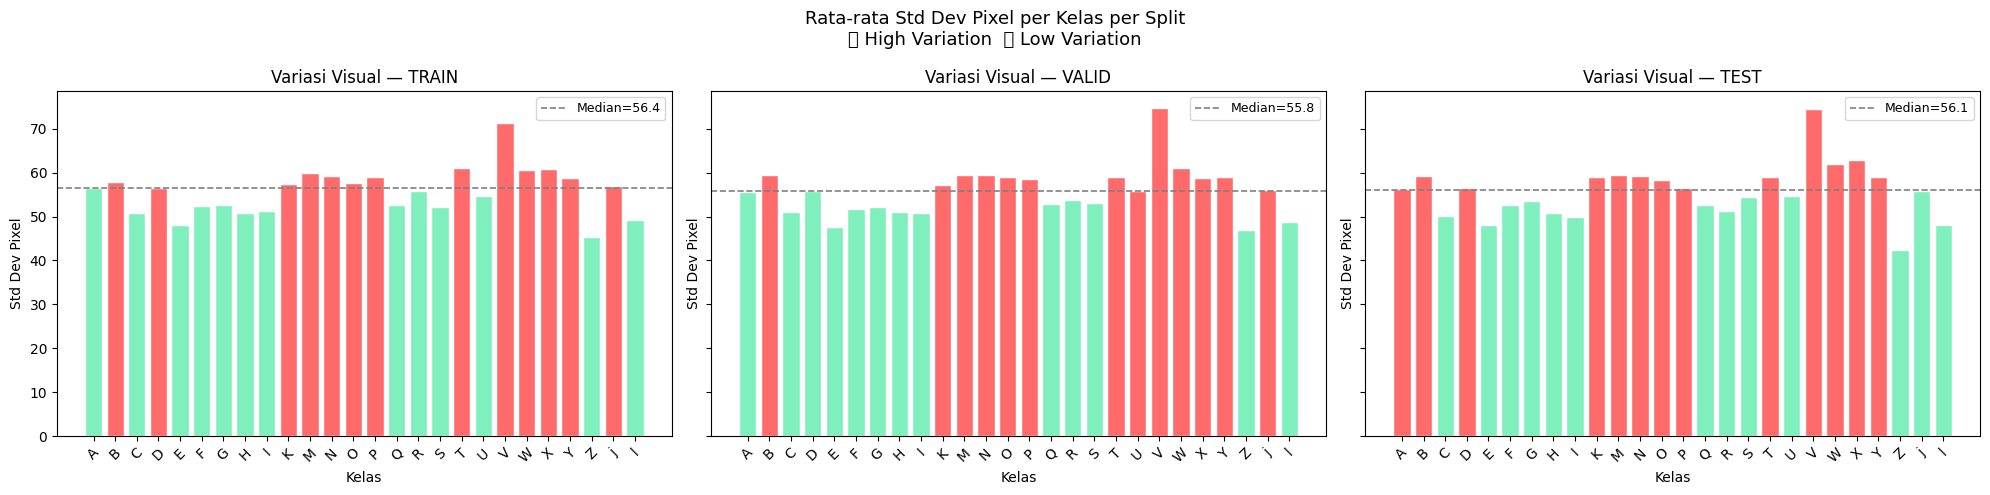

In [18]:
# Visualisasi std dev per kelas untuk semua split (3 subplot)
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)

for ax, split in zip(axes, splits):
    df = std_all[split]
    median = df['Std_Dev'].median()
    colors = ['#ff6b6b' if v >= median else '#7fefbd' for v in df['Std_Dev']]
    ax.bar(df['Class'], df['Std_Dev'], color=colors, edgecolor='white')
    ax.axhline(median, color='gray', linestyle='--', linewidth=1.2, label=f'Median={median:.1f}')
    ax.set_title(f'Variasi Visual — {split.upper()}', fontsize=12)
    ax.set_xlabel('Kelas')
    ax.set_ylabel('Std Dev Pixel')
    ax.legend(fontsize=9)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Rata-rata Std Dev Pixel per Kelas per Split\n🔴 High Variation  🟢 Low Variation', fontsize=13)
plt.tight_layout()
plt.show()

**Insight Pertanyaan 1:**

Berdasarkan visualisasi rata-rata standard deviation pixel per kelas, variasi visual pada dataset BISINDO di split train, valid, dan test terlihat cukup konsisten. Nilai median tiap split juga hampir sama, yaitu sekitar 55–56, sehingga karakteristik visual antar split relatif stabil. Beberapa kelas memiliki variasi visual lebih tinggi dari median, seperti B, K, M, N, O, P, T, V, W, X, dan Y. Hal ini menunjukkan adanya perbedaan visual yang lebih besar pada kelas-kelas tersebut, misalnya dari sisi pencahayaan, warna, tekstur gambar, atau latar belakang. Sebaliknya, beberapa kelas berada di bawah median, seperti E, F, G, H, I, Q, R, S, Z, j, dan l, yang menunjukkan karakteristik visual lebih seragam. Secara umum, dataset memiliki variasi visual yang cukup baik, namun kelas dengan variasi rendah tetap perlu diperhatikan agar model tidak terlalu bergantung pada pola visual yang terlalu seragam.

**Pertanyaan 2:** Apakah terdapat gambar rusak (corrupt), file duplikat, dan ketidaksesuaian format file pada dataset BISINDO di setiap split (train, valid, dan test), serta berapa jumlah dan proporsi masing-masing masalah tersebut?

In [19]:
# Rekap masalah kualitas data per split
rows = []
for split, path in splits.items():
    total = sum(split_counts[split].values())
    n_corrupt = len(corrupt_all[split])
    n_dup = len(duplicates_all[split])
    n_fmt = sum(
        1 for f in os.listdir(path)
        if os.path.isfile(os.path.join(path, f)) and
           not f.lower().endswith(('.jpg', '.jpeg', '.png'))
    )
    rows.append({
        'Split': split.upper(),
        'Total Gambar': total,
        'Corrupt': n_corrupt,
        'Duplikat': n_dup,
        'Format Tidak Sesuai': n_fmt
    })

df_issues = pd.DataFrame(rows)
for col in ['Corrupt', 'Duplikat', 'Format Tidak Sesuai']:
    df_issues[f'{col} (%)'] = (df_issues[col] / df_issues['Total Gambar'] * 100).round(4)

print(df_issues.to_string(index=False))

Split  Total Gambar  Corrupt  Duplikat  Format Tidak Sesuai  Corrupt (%)  Duplikat (%)  Format Tidak Sesuai (%)
TRAIN          6120        0         0                    0          0.0           0.0                      0.0
VALID          1749        0         0                    0          0.0           0.0                      0.0
 TEST           874        0         0                    0          0.0           0.0                      0.0


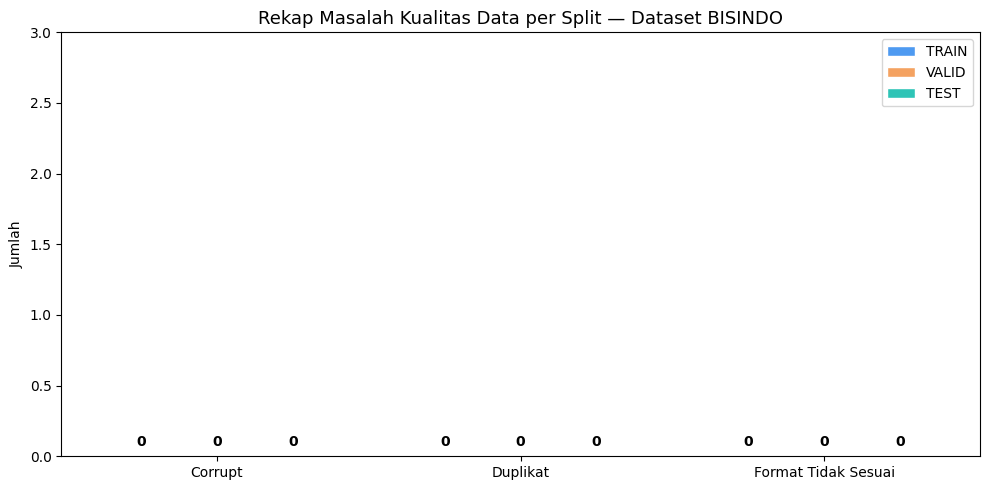

In [20]:
# Visualisasi rekap masalah per split (grouped bar chart)
masalah_cols = ['Corrupt', 'Duplikat', 'Format Tidak Sesuai']
x = np.arange(len(masalah_cols))
width = 0.25
colors_split = {'TRAIN': '#4e9af1', 'VALID': '#f4a261', 'TEST': '#2ec4b6'}

fig, ax = plt.subplots(figsize=(10, 5))
for i, split in enumerate(['TRAIN', 'VALID', 'TEST']):
    row = df_issues[df_issues['Split'] == split].iloc[0]
    vals = [row[c] for c in masalah_cols]
    bars = ax.bar(x + i * width, vals, width, label=split,
                  color=colors_split[split], edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(masalah_cols)
ax.set_title('Rekap Masalah Kualitas Data per Split — Dataset BISINDO', fontsize=13)
ax.set_ylabel('Jumlah')
ax.set_ylim(0, max(df_issues[masalah_cols].max()) + 3)
ax.legend()
plt.tight_layout()
plt.show()

**Insight Pertanyaan 2:**

Tidak terdapat gambar corrupt, file duplikat, maupun format file yang tidak sesuai pada split **train**, **valid**, dan **test**. Seluruh kategori masalah memiliki jumlah **0** dengan proporsi **0,0%**, sehingga dataset BISINDO dapat dikatakan bersih dan konsisten secara teknis.

**Pertanyaan 3:** Bagaimana distribusi jumlah gambar per kelas pada masing-masing split (train, valid, dan test) dataset BISINDO — apakah distribusi kelas sudah seimbang (balanced) dan konsisten di ketiga split?

In [21]:
# Buat dataframe distribusi per split
df_dist_all = {}
for split in splits:
    df = pd.DataFrame(list(split_counts[split].items()), columns=['Class', 'Count'])
    df['Split'] = split.upper()
    total = df['Count'].sum()
    df['Proporsi (%)'] = (df['Count'] / total * 100).round(2)
    df_dist_all[split] = df.sort_values('Count', ascending=False).reset_index(drop=True)

for split, df in df_dist_all.items():
    ratio = df['Count'].max() / max(df['Count'].min(), 1)
    status = '✅ Seimbang' if ratio <= 1.5 else ('⚠️ Cukup Seimbang' if ratio <= 3.0 else '❌ Tidak Seimbang')
    print(f'[{split.upper()}] Balance Ratio: {ratio:.2f} — {status}')
    print(df[['Class', 'Count', 'Proporsi (%)']].to_string(index=False))
    print()

[TRAIN] Balance Ratio: 6.96 — ❌ Tidak Seimbang
Class  Count  Proporsi (%)
    R    397          6.49
    Q    334          5.46
    G    319          5.21
    X    305          4.98
    K    300          4.90
    Z    291          4.75
    M    283          4.62
    T    282          4.61
    A    274          4.48
    N    270          4.41
    E    268          4.38
    I    259          4.23
    V    254          4.15
    Y    252          4.12
    D    250          4.08
    j    228          3.73
    l    226          3.69
    U    211          3.45
    H    202          3.30
    P    186          3.04
    F    166          2.71
    W    162          2.65
    O    150          2.45
    S    133          2.17
    C     61          1.00
    B     57          0.93

[VALID] Balance Ratio: 7.56 — ❌ Tidak Seimbang
Class  Count  Proporsi (%)
    R    121          6.92
    Q     98          5.60
    G     96          5.49
    T     93          5.32
    K     86          4.92
    V     85  

C:\Users\nabila\AppData\Local\Temp\ipykernel_27056\1881630823.py:21: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\nabila\AppData\Local\Temp\ipykernel_27056\1881630823.py:21: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\nabila\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\nabila\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


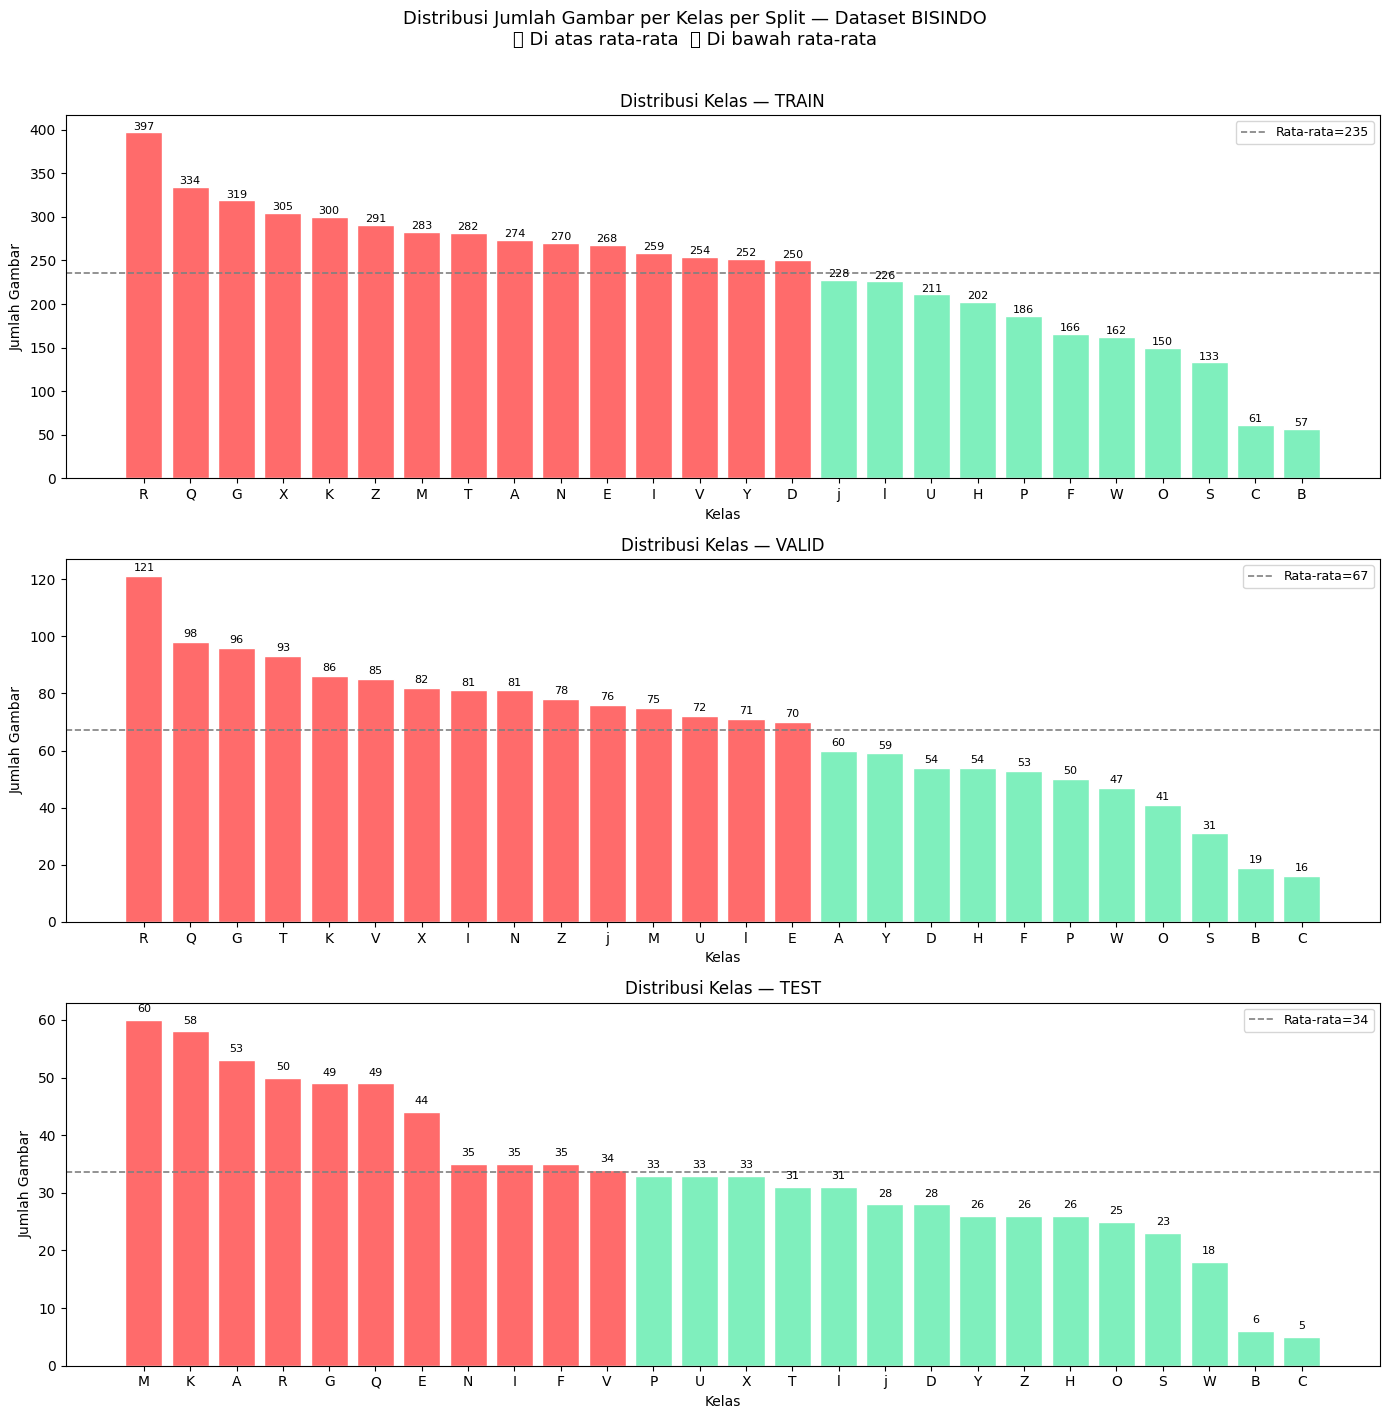

In [22]:
# Visualisasi distribusi kelas per split (3 subplot)
fig, axes = plt.subplots(3, 1, figsize=(14, 14))

for ax, split in zip(axes, splits):
    df = df_dist_all[split]
    mean_count = df['Count'].mean()
    colors = ['#ff6b6b' if v >= mean_count else '#7fefbd' for v in df['Count']]
    bars = ax.bar(df['Class'], df['Count'], color=colors, edgecolor='white')
    ax.axhline(mean_count, color='gray', linestyle='--', linewidth=1.2,
               label=f'Rata-rata={mean_count:.0f}')
    for bar, val in zip(bars, df['Count']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(val), ha='center', va='bottom', fontsize=8)
    ax.set_title(f'Distribusi Kelas — {split.upper()}', fontsize=12)
    ax.set_xlabel('Kelas')
    ax.set_ylabel('Jumlah Gambar')
    ax.legend(fontsize=9)

plt.suptitle('Distribusi Jumlah Gambar per Kelas per Split — Dataset BISINDO\n🔴 Di atas rata-rata  🟢 Di bawah rata-rata',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

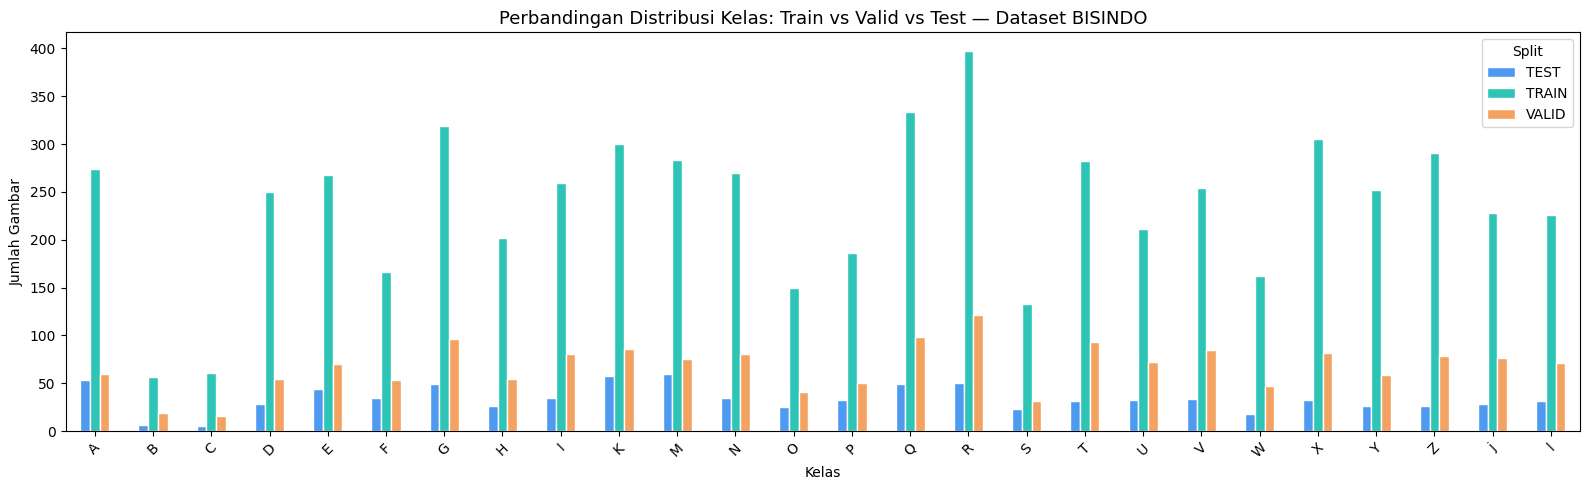

In [23]:
# Perbandingan distribusi ketiga split sekaligus (grouped bar chart)
df_combined = pd.concat(df_dist_all.values())
pivot = df_combined.pivot(index='Class', columns='Split', values='Count').fillna(0)

pivot.plot(kind='bar', figsize=(16, 5),
           color=['#4e9af1', '#2ec4b6', '#f4a261'], edgecolor='white')
plt.title('Perbandingan Distribusi Kelas: Train vs Valid vs Test — Dataset BISINDO', fontsize=13)
plt.xlabel('Kelas')
plt.ylabel('Jumlah Gambar')
plt.xticks(rotation=45)
plt.legend(title='Split')
plt.tight_layout()
plt.show()

**Insight Pertanyaan 3:**

**Insight:**

Distribusi jumlah gambar per kelas pada dataset BISINDO belum seimbang di ketiga split. 
Pada split train, kelas R memiliki jumlah gambar tertinggi sebanyak 397 gambar (6,49%), 
sedangkan kelas B dan C hanya memiliki 57 (0,93%) dan 61 gambar (1,00%). Ketimpangan 
serupa juga terlihat pada split valid, di mana kelas R mencapai 121 gambar (6,92%) 
sementara kelas C hanya 16 gambar (0,91%) dan B hanya 19 gambar (1,09%). Kondisi paling 
ekstrem terjadi pada split test dengan balance ratio 12,00, di mana kelas M memiliki 60 
gambar (6,86%) sedangkan kelas C dan B hanya memiliki 5 (0,57%) dan 6 gambar (0,69%). 
Pola ketimpangan ini muncul secara konsisten di ketiga split dengan balance ratio 
masing-masing 6,96 (train), 7,56 (valid), dan 12,00 (test), sehingga dataset 
dikategorikan ❌ Tidak Seimbang. Kondisi ini perlu ditangani karena model berpotensi 
bias terhadap kelas mayoritas dan kesulitan mengenali kelas minoritas seperti B dan C.

Proses Augmentasi

In [26]:
# ==================================================
# AUGMENTASI DATA GAMBAR BISINDO - TARGETED BALANCED
# TANPA ROTATE / FLIP / TRANSLATE / ZOOM
# ==================================================

random.seed(42)
np.random.seed(42)

# ── KONFIGURASI ──────────────────────────────

SPLITS = {
    "train": "BISINDO-Dataset-1/train/images",
    "valid": "BISINDO-Dataset-1/valid/images",
    "test":  "BISINDO-Dataset-1/test/images",
}

OUTPUT_BASE = "BISINDO-Augmented-Balanced"
TARGET      = 400   # semua kelas train akan di-balance ke angka ini
MAX_WORKERS = 4

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}


# ── FUNGSI AUGMENTASI ─────────────────────────

def aug_brightness(img):
    pil = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    pil = ImageEnhance.Brightness(pil).enhance(random.uniform(0.8, 1.2))
    return cv2.cvtColor(np.array(pil), cv2.COLOR_RGB2BGR)

def aug_contrast(img):
    pil = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    pil = ImageEnhance.Contrast(pil).enhance(random.uniform(0.85, 1.15))
    return cv2.cvtColor(np.array(pil), cv2.COLOR_RGB2BGR)

def aug_noise(img):
    noise = np.random.normal(0, 4, img.shape).astype(np.int16)
    return np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

def aug_hsv(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV).astype(np.int32)
    hsv[:, :, 0] = np.clip(hsv[:, :, 0] + random.randint(-3, 3), 0, 179)
    hsv[:, :, 1] = np.clip(hsv[:, :, 1] + random.randint(-15, 15), 0, 255)
    hsv[:, :, 2] = np.clip(hsv[:, :, 2] + random.randint(-20, 20), 0, 255)
    return cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)

AUG_POOL = [aug_brightness, aug_contrast, aug_noise, aug_hsv]

def apply_aug(img):
    augmented = img.copy()
    for fn in random.sample(AUG_POOL, random.randint(2, 3)):
        augmented = fn(augmented)
    return augmented


# ── FUNGSI AMBIL FILE ─────────────────────────

def get_image_files(src_path):
    return sorted([
        f for f in src_path.iterdir()
        if f.is_file() and f.suffix.lower() in IMAGE_EXTENSIONS
    ])

def get_class_files(files):
    class_files = {}
    for f in files:
        cls = f.name.split("-")[0]
        class_files.setdefault(cls, []).append(f)
    return class_files


# ── PROSES PER FILE (untuk valid/test — salin saja) ──────────

def process_copy(args):
    src, dst_dir = args
    try:
        img = cv2.imread(str(src))
        if img is None:
            print(f"[GAGAL DIBACA] {src}")
            return 0
        cv2.imwrite(str(dst_dir / src.name), img)
        return 1
    except Exception as e:
        print(f"[ERROR] {src}: {e}")
        return 0


# ── MAIN PROCESS ─────────────────────────────

summary = []

for split, src_dir in SPLITS.items():
    src_path = Path(src_dir)

    if not src_path.exists():
        print(f"[SKIP] Folder tidak ditemukan: {src_dir}")
        continue

    dst_path = Path(OUTPUT_BASE) / split / "images"
    dst_path.mkdir(parents=True, exist_ok=True)

    files      = get_image_files(src_path)
    total_output = 0

    print("\n" + "=" * 55)
    print(f"SPLIT              : {split.upper()}")
    print(f"Jumlah gambar asli : {len(files)}")

    if split == "train":
        # ── TARGETED AUGMENTASI HANYA UNTUK TRAIN ────────────
        class_files = get_class_files(files)
        print(f"Target per kelas   : {TARGET}")
        print(f"Estimasi output    : {len(class_files) * TARGET}")
        print("=" * 55)
        print(f"{'Kelas':<8} {'Asli':>6} {'+Aug':>8} {'Total':>7}")
        print("-" * 35)

        for cls, cls_files in tqdm(sorted(class_files.items()), desc="Augmentasi train"):
            need = TARGET - len(cls_files)

            # Salin semua gambar asli
            for f in cls_files:
                img = cv2.imread(str(f))
                if img is not None:
                    cv2.imwrite(str(dst_path / f.name), img)

            # Generate tambahan kalau masih kurang dari TARGET
            generated = 0
            if need > 0:
                pool = (cls_files * (need // len(cls_files) + 2))[:need]
                random.shuffle(pool)
                for i, src in enumerate(pool):
                    img = cv2.imread(str(src))
                    if img is None:
                        continue
                    aug_name = f"{src.stem}_bal{i+1}{src.suffix}"
                    cv2.imwrite(str(dst_path / aug_name), apply_aug(img))
                    generated += 1

            total_cls = len(cls_files) + generated
            total_output += total_cls
            print(f"{cls:<8} {len(cls_files):>6} {generated:>+8} {total_cls:>7}")

        print("-" * 35)

    else:
        # ── VALID & TEST: SALIN APA ADANYA ───────────────────
        print(f"Mode               : Salin tanpa augmentasi")
        print("=" * 55)

        args_list = [(f, dst_path) for f in files]
        with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
            futures = [executor.submit(process_copy, a) for a in args_list]
            for future in tqdm(as_completed(futures), total=len(futures), desc=f"Menyalin {split}"):
                total_output += future.result()

    summary.append({
        "split"             : split,
        "jumlah_gambar_asli": len(files),
        "total_output"      : total_output,
        "folder_output"     : str(dst_path)
    })
    print(f"Total file output  : {total_output}")
    print(f"Disimpan di        : {dst_path}")


# ── RINGKASAN HASIL ──────────────────────────

print("\n" + "=" * 55)
print("AUGMENTASI SELESAI")
print("=" * 55)
print(f"Folder utama output: {OUTPUT_BASE}\n")

for item in summary:
    print(
        f"{item['split'].upper():<6} | "
        f"asli: {item['jumlah_gambar_asli']:>5} | "
        f"total output: {item['total_output']}"
    )


SPLIT              : TRAIN
Jumlah gambar asli : 6120
Target per kelas   : 400
Estimasi output    : 10400
Kelas      Asli     +Aug   Total
-----------------------------------


Augmentasi train:   4%|▍         | 1/26 [00:03<01:25,  3.41s/it]

A           274     +126     400


Augmentasi train:   8%|▊         | 2/26 [00:08<01:47,  4.48s/it]

B            57     +343     400


...

l           226     +174     400
-----------------------------------
Total file output  : 10400
Disimpan di        : BISINDO-Augmented-Balanced\train\images

SPLIT              : VALID
Jumlah gambar asli : 1749
Mode               : Salin tanpa augmentasi


Menyalin valid: 100%|██████████| 1749/1749 [00:02<00:00, 609.90it/s]


Total file output  : 1749
Disimpan di        : BISINDO-Augmented-Balanced\valid\images

SPLIT              : TEST
Jumlah gambar asli : 874
Mode               : Salin tanpa augmentasi


Menyalin test: 100%|██████████| 874/874 [00:01<00:00, 565.45it/s]

Total file output  : 874
Disimpan di        : BISINDO-Augmented-Balanced\test\images

AUGMENTASI SELESAI
Folder utama output: BISINDO-Augmented-Balanced

TRAIN  | asli:  6120 | total output: 10400
VALID  | asli:  1749 | total output: 1749
TEST   | asli:   874 | total output: 874


**Insight:**

Setelah dilakukan targeted augmentasi pada split train, distribusi kelas mengalami 
perbaikan signifikan. Seluruh 26 kelas pada split train kini memiliki jumlah gambar 
yang sama persis, yaitu 400 gambar per kelas dengan total 10.400 gambar, sehingga 
balance ratio turun drastis dari 6,96 menjadi 1,00 (✅ Seimbang). Kelas yang 
sebelumnya sangat kekurangan data seperti B (57 → 400) dan C (61 → 400) kini 
setara dengan kelas mayoritas seperti R yang sebelumnya mendominasi dengan 397 gambar.

Sementara itu, split valid dan test sengaja tidak dilakukan augmentasi sehingga 
distribusinya tetap mencerminkan data asli. Split valid masih memiliki balance ratio 
7,56 (❌ Tidak Seimbang) dengan kelas R sebagai mayoritas (121 gambar, 6,92%) dan 
kelas C sebagai minoritas (16 gambar, 0,91%). Split test memiliki ketimpangan paling 
ekstrem dengan balance ratio 12,00 (❌ Tidak Seimbang), di mana kelas M mendominasi 
dengan 60 gambar (6,86%) sementara kelas C hanya memiliki 5 gambar (0,57%). Kondisi 
ini dibiarkan apa adanya karena valid dan test berfungsi sebagai cerminan distribusi 
data dunia nyata untuk evaluasi model yang objektif.